In [2]:
import pandas as pd
import numpy as np
import sys 
import os 

from sklearn import set_config
from sklearn.model_selection import train_test_split
from sksurv.linear_model import CoxnetSurvivalAnalysis
set_config(display="text")  # displays text representation of estimators


from sksurv.metrics import concordance_index_censored

from sksurv.util import Surv
sys.path.append(os.path.abspath("../../"))
from src.utils.ConvertTextToCsv import TextToCsv
from src.utils.Preprocessing import Preprocessor
from src.utils.plots import Plots
from src.utils.cox_models import *
%load_ext autoreload
%autoreload 2
%matplotlib inline


In [3]:
pp = Preprocessor()
plots_class = Plots()

In [4]:
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_data = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_data)
df_clinical_data["Tumor-Cancer"] = list_df
df_clinical_data["Tumor-Cancer"].unique()

df_mRNA_raw_data = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")


Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 299 - Total(%) 0.37
Shape of the CSV: (20440, 819)


In [5]:
clean_mRNA_df = pp.eliminate_zero_genes(df_mRNA_raw_data, "Hugo_Symbol")

Genes before Treshold: 818
count     818.000000
mean     2911.273839
std       351.415192
min         0.000000
25%      2709.250000
50%      2866.500000
75%      3078.500000
max      4575.000000
dtype: float64
Threshold (>80% zeros): 16352 samples
After the treshold: 818


In [6]:
genes_expression = clean_mRNA_df["Hugo_Symbol"].sample(100, axis=0)

genes_expression

3783        CKMT2
10253      LRRC48
16533     SNORA19
2957       CARNS1
13650        POLB
           ...   
20350      ZNF827
12746         OXT
13208        PGA3
12833       PANK1
2365     KIAA0930
Name: Hugo_Symbol, Length: 100, dtype: object

In [95]:
expressions_genes_cols = pd.DataFrame()
for index, gene in enumerate(genes_expression):
    df_final_genes = pp.gene_to_long(clean_mRNA_df, gene)
    
    if index == 0:
        expressions_genes_cols = df_final_genes[["Sample ID", "expression"]].rename(columns={"expression": gene}).copy()
    else:
        expressions_genes_cols = expressions_genes_cols.merge(
            df_final_genes[["Sample ID", "expression"]].rename(columns={"expression": gene}),
            on="Sample ID",
            how="inner"
            )
        
expressions_genes_cols


,Sample ID,SEPT11,AATK-AS1,CEMP1,SLC5A7,PGAM4,VASP,EXOC2,HOATZ,FOXRED1,...,PTDSS2,PUS1,SCAF1,OXCT1,DMKN,FAR2,KDF1,ARHGAP12,DPH2,PSMD5-AS1
0,TCGA-A1-A0SB-01,1301.4979,0.4505,109.9223,0.0,40.9956,1249.2398,663.1377,2.703,374.817,...,431.1296,309.4943,1585.7642,947.8545,476.1797,42.2615,401.8471,1003.2661,658.6327,835.2292
1,TCGA-A1-A0SD-01,2090.1497,0.3308,111.5143,2.6466,57.8943,1835.4148,1345.7944,2.3158,266.9754,...,611.033,201.1413,1412.621,923.3314,298.7346,126.375,330.4938,1203.5398,301.0504,524.357
2,TCGA-A1-A0SE-01,4155.6561,0.0,154.3891,2.6327,35.87,1477.2522,1278.4862,1.6454,254.71,...,639.7367,150.3908,1544.7141,588.0708,338.297,82.919,413.6569,1413.4101,492.6368,393.5829
3,TCGA-A1-A0SF-01,2847.5986,0.0,219.2441,0.0,46.696,2585.4156,2848.027,3.4272,563.3507,...,672.1652,291.7428,2005.7856,295.1701,333.298,32.5587,457.535,682.0185,711.15,446.8249
4,TCGA-A1-A0SH-01,9448.4748,0.0,99.5698,0.0,47.6721,1871.854,967.889,0.7223,227.5261,...,470.5819,174.7979,1542.844,734.9456,65.3686,130.3508,265.086,1029.285,473.1099,518.9763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
812,TCGA-MS-A51U-01,2911.3198,1.0433,268.7428,0.5216,34.9504,2629.108,642.1492,0.0,485.133,...,579.5514,320.2921,3172.6656,348.4611,1881.0642,80.3339,407.9291,1036.5154,435.5764,774.6479
813,TCGA-OL-A66H-01,1066.7223,0.0,317.206,0.0,51.2927,2874.4787,867.3895,12.5104,478.3153,...,904.0867,477.8982,2210.1751,666.3887,352.377,223.9033,482.9024,558.382,750.6255,559.216
814,TCGA-OL-A66I-01,2760.5634,0.4173,324.7491,0.0,34.6375,4772.457,782.4726,4.5905,481.1685,...,475.326,681.8988,2514.3453,1060.8242,2472.1961,106.4163,338.8628,471.5702,638.915,701.5128
815,TCGA-OL-A66J-01,3015.3222,0.0,495.7188,4.9572,40.5588,2967.553,921.1356,0.9013,233.4385,...,1131.5908,378.9995,2189.7251,544.84,689.0491,63.0915,273.9973,806.219,517.8008,56.7823


In [96]:
df_merged = pd.merge(left=df_clinical_data, right=expressions_genes_cols, left_on="Sample ID", right_on="Sample ID")


In [97]:
cols = ["Sample ID","Tumor-Cancer", "Overall Survival Status", "Overall Survival (Months)"] + list(expressions_genes_cols)

comparation_df = df_merged.loc[
    df_merged["Tumor-Cancer"].isin(["Luminal A", "Luminal B", "TNBC", "HER2-enriched"]),
    cols
]
comparation_df = pp.eliminate_zero_genes(comparation_df, "Tumor-Cancer", threshold=0.8)



Genes before Treshold: 104
count    106.000000
mean      83.716981
std      167.327950
min        0.000000
25%        0.000000
50%        0.000000
75%       10.750000
max      519.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 96


In [98]:
status = comparation_df["Overall Survival Status"].astype(str).str.strip()

comparation_df["event"] = status.str.contains("DECEASED", na=False)

comparation_df["event_60"] = comparation_df["event"].copy()
comparation_df["time_60"] =  np.minimum(comparation_df["Overall Survival (Months)"], 60)
comparation_df.loc[
    comparation_df["Overall Survival (Months)"] > 60, "event_60"
] = False

comparation_df = comparation_df.dropna(subset=["time_60"]).copy()

groups = comparation_df["Sample ID"]
comparation_df = comparation_df.drop(columns="Sample ID")


X = comparation_df.iloc[:, 3:-3].astype(float)

In [99]:
X_log = np.log2(X + 1)
Y = Surv.from_dataframe(
    event="event_60",
    time="time_60",
    data=comparation_df
)

In [100]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_log, Y, train_size=0.80, test_size=0.20, random_state=42
)

<font size="4">Cox Lasso</font>

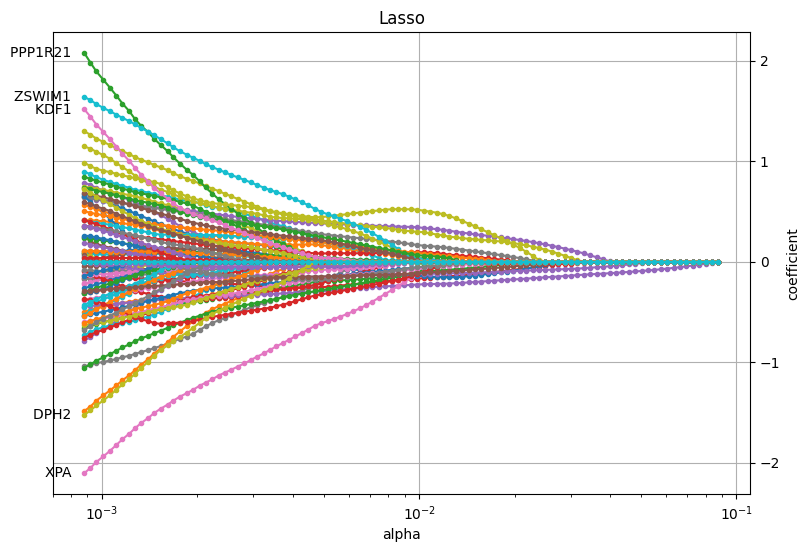

In [101]:
cox_Lasso = CoxnetSurvivalAnalysis(l1_ratio=1.0, alpha_min_ratio=0.01)
cox_Lasso.fit(X_train, Y_train)
coefficient_lasso = pd.DataFrame(cox_Lasso.coef_, index=X.columns, columns=np.round(cox_Lasso.alphas_, 5))
plot_coefficients(coefficient_lasso, n_highlight=5, title="Lasso")


In [102]:
best_idx_lasso, scores_lasso = C_index(cox_Lasso.alphas_, cox_Lasso.coef_, X_train, Y_train)

In [103]:
best_alpha = cox_Lasso.alphas_[best_idx_lasso]
best_alpha

0.0008777673473225806

In [104]:
coefs = cox_Lasso.coef_[:, best_idx_lasso]

In [105]:
coef_series = pd.Series(coefs, index=X_train.columns)

important_genes_sorted = coef_series[coef_series != 0] \
    .sort_values(key=abs, ascending=False)
important_genes_top = important_genes_sorted.head(10)
important_genes_top

XPA         -2.104786
PPP1R21      2.075822
ZSWIM1       1.639325
DPH2        -1.525242
KDF1         1.515584
MANF        -1.485597
SLC9A3R2     1.297678
FLYWCH1      1.146375
SERPINF2    -1.055334
LINC02909   -1.041429
dtype: float64

In [127]:
"""for name_gene, betas_gene in important_genes_top.items():
    p_value, log_rang_test = p_values_log_rank(df_merged)"""

comparation_df

,Tumor-Cancer,Overall Survival Status,Overall Survival (Months),SEPT11,AATK-AS1,CEMP1,SLC5A7,PGAM4,VASP,EXOC2,...,OXCT1,DMKN,FAR2,KDF1,ARHGAP12,DPH2,PSMD5-AS1,event,event_60,time_60
2,Luminal A,0:LIVING,43.400000,4155.6561,0.0,154.3891,2.6327,35.87,1477.2522,1278.4862,...,588.0708,338.297,82.919,413.6569,1413.4101,492.6368,393.5829,False,False,43.400000
6,Luminal A,0:LIVING,13.670000,3437.037,0.3658,93.9223,0.7316,31.0928,1806.31,1180.7956,...,1229.8125,182.5332,182.5222,533.6991,1474.5313,406.0357,421.0334,False,False,13.670000
7,TNBC,1:DECEASED,31.770000,3352.9783,0.3152,54.554,2.2061,41.2858,820.3593,1192.8774,...,2380.3971,219.9811,54.0309,557.2014,436.8106,744.0908,1067.4441,True,True,31.770000
8,Luminal B,0:LIVING,7.950000,3710.5429,0.0,107.5095,14.5202,34.4066,2006.3131,1013.8889,...,691.6035,287.8788,200.101,293.2449,482.9545,574.4949,307.1338,False,False,7.950000
10,TNBC,0:LIVING,19.190000,3408.61,0.0,96.3262,0.0,33.1996,2179.8614,693.9073,...,2694.2722,701.2039,380.0146,732.2145,453.4841,1640.2773,223.2762,False,False,19.190000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
812,Luminal A,0:LIVING,22.370000,2911.3198,1.0433,268.7428,0.5216,34.9504,2629.108,642.1492,...,348.4611,1881.0642,80.3339,407.9291,1036.5154,435.5764,774.6479,False,False,22.370000
813,Luminal A,0:LIVING,26.695598,1066.7223,0.0,317.206,0.0,51.2927,2874.4787,867.3895,...,666.3887,352.377,223.9033,482.9024,558.382,750.6255,559.216,False,False,26.695598
814,TNBC,0:LIVING,23.460000,2760.5634,0.4173,324.7491,0.0,34.6375,4772.457,782.4726,...,1060.8242,2472.1961,106.4163,338.8628,471.5702,638.915,701.5128,False,False,23.460000
815,Luminal A,0:LIVING,65.570000,3015.3222,0.0,495.7188,4.9572,40.5588,2967.553,921.1356,...,544.84,689.0491,63.0915,273.9973,806.219,517.8008,56.7823,False,False,60.000000


<font size="4">Elastic Net</font>

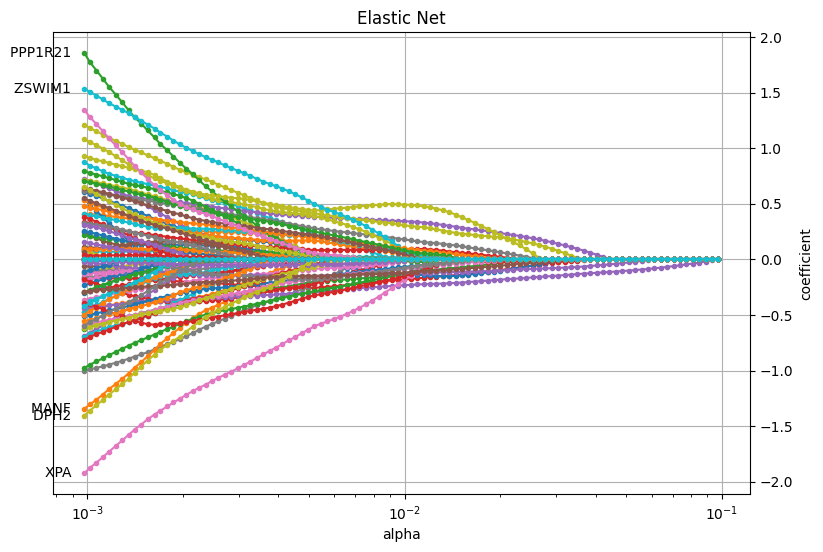

In [106]:
cox_elastic_net = CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01)
cox_elastic_net.fit(X_train, Y_train)
coffiencients_elastic_net = pd.DataFrame(
    cox_elastic_net.coef_, index=X.columns, columns=np.round(cox_elastic_net.alphas_, 5)
)

plot_coefficients(coffiencients_elastic_net, n_highlight=5, title="Elastic Net")


In [110]:
best_idx_elastinc_net, scores_elastic_net = C_index(cox_elastic_net.alphas_, cox_elastic_net.coef_, X_train, Y_train)
best_alpha = cox_elastic_net.alphas_[best_idx_elastinc_net]
coefs_elastic_net = cox_elastic_net.coef_[:, best_idx_elastinc_net]

In [111]:
coef_series_elastic_net = pd.Series(coefs_elastic_net, index=X_train.columns)

important_genes_sorted_elastic_net = coef_series_elastic_net[coef_series_elastic_net != 0].sort_values(key=abs, ascending=False)
important_genes_top_elastic_net = important_genes_sorted_elastic_net.head(10)
important_genes_top_elastic_net

XPA         -1.923040
PPP1R21      1.854900
ZSWIM1       1.535089
DPH2        -1.405324
MANF        -1.343566
KDF1         1.342522
SLC9A3R2     1.210424
FLYWCH1      1.078966
LINC02909   -1.001497
SERPINF2    -0.976188
dtype: float64

<font size="4">Cox Ridge</font>

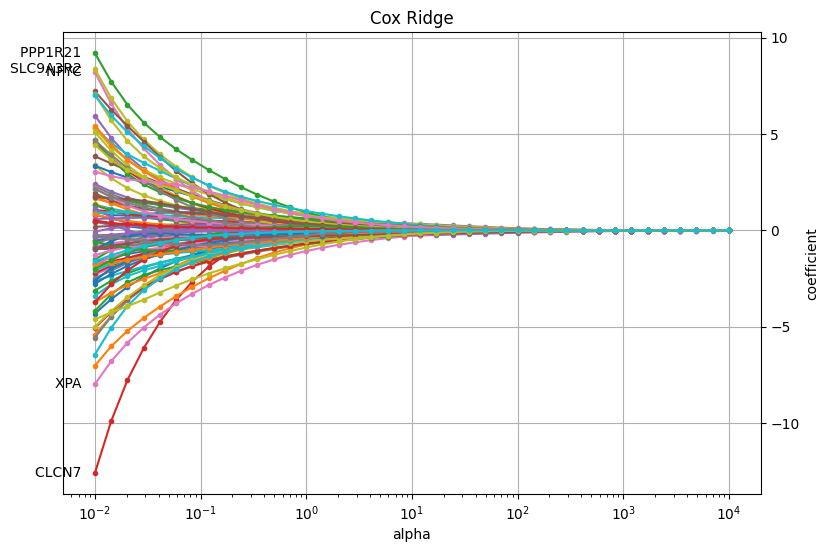

In [118]:
betas_ridge, chp_predict_ridge, chp_survival_curve_ridge, chp_risk_curve_ridge = Cox_l2_regression(
    X_train, Y_train, X_test, draw_plot=False, title="Ridge"
)

plot_coefficients(betas_ridge, n_highlight=5, title="Cox Ridge")


In [17]:
import warnings
from sklearn.exceptions import FitFailedWarning
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
coxnet_pipe = make_pipeline(StandardScaler(), CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01, max_iter=100))
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FitFailedWarning)

coxnet_pipe.fit(X_log, Y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('coxnetsurvivalanalysis',
                 CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l1_ratio=0.9,
                                        max_iter=100))])

In [18]:
estimated_alphas = coxnet_pipe.named_steps["coxnetsurvivalanalysis"].alphas_
cv = KFold(n_splits=5, shuffle=True, random_state=42)
gcv = GridSearchCV(
    make_pipeline(StandardScaler(), CoxnetSurvivalAnalysis(l1_ratio=0.9)),
    param_grid={"coxnetsurvivalanalysis__alphas": [[v] for v in map(float, estimated_alphas)]},
    cv=cv,
    error_score=0.5,
    n_jobs=1
).fit(X, Y)

In [19]:
cv_results = pd.DataFrame(gcv.cv_results_)

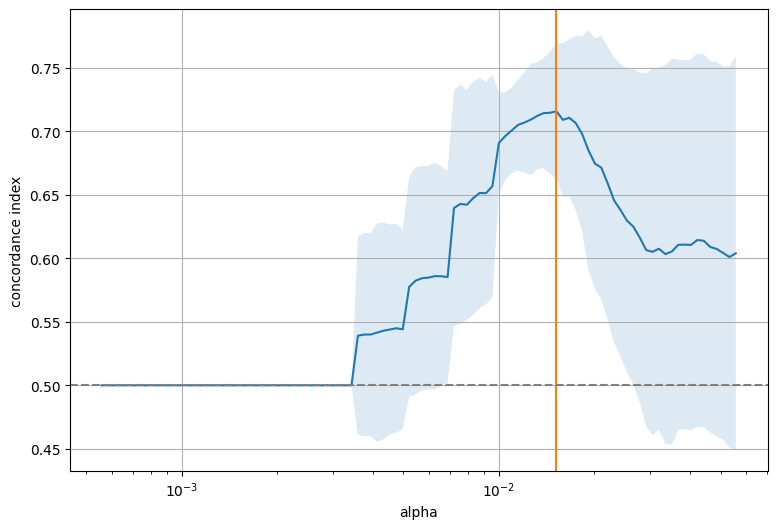

In [20]:
alphas = cv_results.param_coxnetsurvivalanalysis__alphas.map(lambda x: x[0])
mean = cv_results.mean_test_score
std = cv_results.std_test_score

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(alphas, mean)
ax.fill_between(alphas, mean - std, mean + std, alpha=0.15)
ax.set_xscale("log")
ax.set_ylabel("concordance index")
ax.set_xlabel("alpha")
ax.axvline(gcv.best_params_["coxnetsurvivalanalysis__alphas"][0], c="C1")
ax.axhline(0.5, color="grey", linestyle="--")
ax.grid(True)

Number of non-zero coefficients: 18


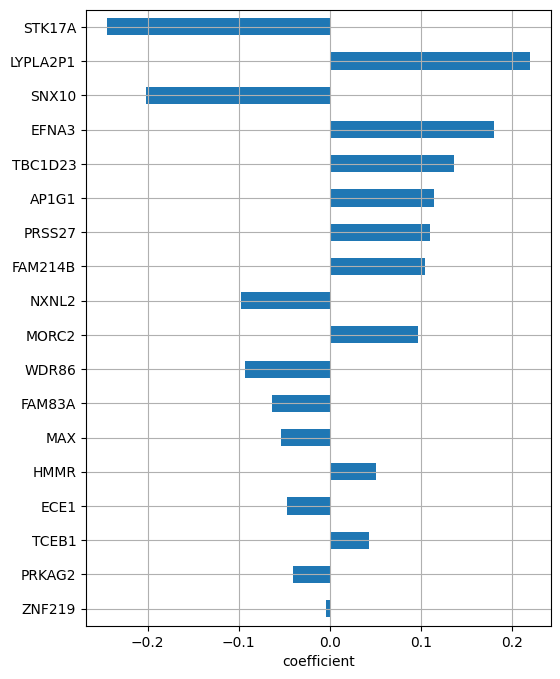

In [21]:
best_model = gcv.best_estimator_.named_steps["coxnetsurvivalanalysis"]
best_coefs = pd.DataFrame(best_model.coef_, index=X.columns, columns=["coefficient"])

non_zero = np.sum(best_coefs.iloc[:, 0] != 0)
print(f"Number of non-zero coefficients: {non_zero}")

non_zero_coefs = best_coefs.query("coefficient != 0")
coef_order = non_zero_coefs.abs().sort_values("coefficient").index

_, ax = plt.subplots(figsize=(6, 8))
non_zero_coefs.loc[coef_order].plot.barh(ax=ax, legend=False)
ax.set_xlabel("coefficient")
ax.grid(True)